# EEG Artifact Removal Pipeline (DBS + Blinks)

This notebook guides you through the correct process to remove blink artifacts
from EEG data that is heavily contaminated with a 7 Hz DBS artifact.

**The Strategy:**
1.  **Set Channel Types:** Correctly label EEG, EOG, ECG, and EMG channels.
2.  **Apply General Filters:** Apply a standard band-pass filter (e.g., 0.5-40 Hz) and a 60 Hz notch filter.
3.  **Create an ICA-Specific Copy:** Make a *new* copy of the data just for *fitting* ICA.
4.  **Clean the ICA Data:** On this new copy, apply a 1 Hz high-pass (required for ICA) and—most importantly—**notch out the 7 Hz DBS harmonics**.
5.  **Fit ICA:** Fit ICA on this *super-clean* data. It will now be able to "see" the blinks.
6.  **Find Blinks:** Find the blink components using the `Fp1` and `Fp2` channels as a reference.
7.  **Apply ICA:** Use the "solution" from ICA to remove blinks from the *original filtered data* (from Step 2).

## Imports

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mne.preprocessing import ICA
from scipy.integrate import simpson

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10
mne.viz.set_browser_backend('matplotlib')

print("Libraries imported successfully!")
print(f"MNE version: {mne.__version__}")

Using matplotlib as 2D backend.
Libraries imported successfully!
MNE version: 1.10.2


## Step 1: Load Data

In [2]:
def load_eeg_data(patient: str, dbs_freq: int, base_path: str) -> tuple:
    """Load EEG data based on patient ID, DBS frequency, and sleep state."""
    file_path_sleep = f"{base_path}/{patient}/{patient}SLEEP{dbs_freq}.EDF"
    file_path_awake = f"{base_path}/{patient}/{patient}AWAKE{dbs_freq}.EDF"
    raw_sleep = mne.io.read_raw_edf(file_path_sleep, preload=True, verbose=False)
    raw_awake = mne.io.read_raw_edf(file_path_awake, preload=True, verbose=False)
    return raw_sleep, raw_awake

In [3]:
# ## STEP 1: Load EDF Data

# %%
print("\n" + "="*80)
print("STEP 1: LOADING EDF DATA")
print("="*80)

# Configuration
patient = "XU"
dbs_freq = 7  # Hz
base_path = "../data"


STEP 1: LOADING EDF DATA


In [4]:
# Load data
raw_sleep, raw_awake = load_eeg_data(patient, dbs_freq, base_path)

## Step 2: Set Channel Types

In [5]:
def set_custom_channel_types(raw_object):
    """Set channel types based on custom naming conventions."""
    eeg_10_20 = {
        'Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2',
        'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz', 'A1', 'A2', 'Fpz'
    }
    # T1 and T2 are also EEG in your setup
    ext_eeg = {'T1', 'T2'}

    # This dictionary maps channel names to types
    ch_types = {}
    for ch in raw_object.ch_names:
        if ch in eeg_10_20 or ch in ext_eeg:
            ch_types[ch] = 'eeg'
        elif ch.startswith('EKG'):
            ch_types[ch] = 'ecg'
        elif ch.startswith('LOC') or ch.startswith('ROC'):
            ch_types[ch] = 'eog'
        elif ch.startswith('EMG'):
            ch_types[ch] = 'emg'
        elif ch.startswith('X') or ch.startswith('DC') or ch in ['OSAT', 'PR']:
            ch_types[ch] = 'misc' # 'stim' or 'misc' are good choices
        else:
            ch_types[ch] = 'misc' # Default for any un-matched
            
    raw_object.set_channel_types(ch_types)
    print(f"✓ Channel types set for {len(raw_object.ch_names)} channels.")
    print(f"New types: {set(raw_object.get_channel_types())}")

In [6]:
set_custom_channel_types(raw_sleep)
set_custom_channel_types(raw_awake)

✓ Channel types set for 46 channels.
New types: {'ecg', 'eeg', 'eog', 'misc', 'emg'}
✓ Channel types set for 46 channels.
New types: {'ecg', 'eeg', 'eog', 'misc', 'emg'}


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_58774/3593621220.py:26: RuntimeWarning: The unit for channel(s) DC1, DC2, DC3, DC4, OSAT, PR, X10, X11, X12, X13, X14, X15, X16, X17, X18, X9 has changed from V to NA.
  raw_object.set_channel_types(ch_types)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_58774/3593621220.py:26: RuntimeWarning: The unit for channel(s) DC1, DC2, DC3, DC4, OSAT, PR, X10, X11, X12, X13, X14, X15, X16, X17, X18, X9 has changed from V to NA.
  raw_object.set_channel_types(ch_types)


## Step 3: Set Reference & Montage

In [7]:
# Set reference
try:
    raw_awake.set_eeg_reference(ref_channels=['A1', 'A2'])
    raw_sleep.set_eeg_reference(ref_channels=['A1', 'A2'])
    print("✓ Reference set to A1 and A2.")
except:
    raw_awake.set_eeg_reference(ref_channels='average')
    raw_sleep.set_eeg_reference(ref_channels='average')
    print("✓ Could not find A1/A2, using average reference instead.")

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
✓ Reference set to A1 and A2.


In [10]:
raw_sleep_1020 = raw_sleep.copy().drop_channels(['T1', 'T2'])
raw_awake_1020 = raw_awake.copy().drop_channels(['T1', 'T2'])

In [12]:
# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw_awake_1020.set_montage(montage, on_missing='warn')
print("✓ Montage set to standard 10-20 system.")
raw_sleep_1020.set_montage(montage, on_missing='warn')
print("✓ Montage set to standard 10-20 system.")

✓ Montage set to standard 10-20 system.
✓ Montage set to standard 10-20 system.


## Step 4: Apply General Filters

In [13]:
raw_filtered_awake_1020 = raw_awake_1020.copy().filter(0.5, 40, fir_design='firwin')
print("✓ Applied 0.5-40 Hz bandpass filter to awake data.")
raw_filtered_sleep_1020 = raw_sleep_1020.copy().filter(0.5, 40, fir_design='firwin')
print("✓ Applied 0.5-40 Hz bandpass filter to sleep data.")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

✓ Applied 0.5-40 Hz bandpass filter to awake data.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-

In [14]:
# remove powerline noise at 60 Hz and its harmonics
raw_filtered_awake_1020.notch_filter(freqs=[60, 120], fir_design='firwin')
print("✓ Applied notch filter at 60 Hz and 120 Hz to awake data.")
raw_filtered_sleep_1020.notch_filter(freqs=[60, 120], fir_design='firwin')
print("✓ Applied notch filter at 60 Hz and 120 Hz to sleep data.")

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

✓ Applied notch filter at 60 Hz and 120 Hz to awake data.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

✓ Applied notch filter at 60 Hz and 120 Hz to sleep data.


## Step 5: Prepare a Special Copy for ICA (The Core Fix)

This is the most important part. We create a *new* copy of the data
just for *fitting* ICA. This copy will be heavily filtered.

1.  **High-pass at 1.0 Hz:** ICA is sensitive to slow drifts.
2.  **Notch filter DBS:** We *must* remove the 7 Hz DBS harmonics.

In [15]:
raw_awake_1020_for_ica = raw_filtered_awake_1020.copy()
raw_sleep_1020_for_ica = raw_filtered_sleep_1020.copy()

In [16]:
raw_awake_1020_for_ica.filter(1.0, None, fir_design='firwin')
print("✓ Applied high-pass filter at 1.0 Hz to awake data for ICA.")
raw_sleep_1020_for_ica.filter(1.0, None, fir_design='firwin')
print("✓ Applied high-pass filter at 1.0 Hz to sleep data for ICA.")

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)

✓ Applied high-pass filter at 1.0 Hz to awake data for ICA.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)

✓ Applied high-pass filter at 1.0 Hz to slee

In [17]:
sfreq = raw_awake_1020_for_ica.info['sfreq']
n_harmonics = int((sfreq / 2) // dbs_freq)
dbs_freq = 7
dbs_harmonics = [dbs_freq * (i + 1) for i in range(n_harmonics)]

In [18]:
raw_awake_1020_for_ica.notch_filter(freqs=dbs_harmonics, fir_design='firwin')
print("✓ Applied notch filter at DBS harmonics to awake data for ICA.")
raw_sleep_1020_for_ica.notch_filter(freqs=dbs_harmonics, fir_design='firwin')
print("✓ Applied notch filter at DBS harmonics to sleep data for ICA.")

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

✓ Applied notch filter at DBS harmonics to awake data for ICA.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

✓ Applied notch filter at DBS harmonics to sleep data for ICA.


## Step 6: Fit ICA

In [21]:
ica_awake = ICA(
    n_components=0.95,  # Select components explaining 95% of variance
    max_iter='auto',
    random_state=97
)
ica_awake.fit(raw_awake_1020_for_ica)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by explained variance: 8 components
Fitting ICA took 0.4s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,19 iterations on raw data (145408 samples)
ICA components,8
Available PCA components,22
Channel types,eeg
ICA components marked for exclusion,—


In [22]:
ica_sleep = ICA(
    n_components=0.95,  # Select components explaining 95% of variance
    max_iter='auto',
    random_state=97
)
ica_sleep.fit(raw_sleep_1020_for_ica)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by explained variance: 8 components
Fitting ICA took 0.5s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,23 iterations on raw data (163328 samples)
ICA components,8
Available PCA components,22
Channel types,eeg
ICA components marked for exclusion,—


## Step 7: Find Blink Components (The Right Way)

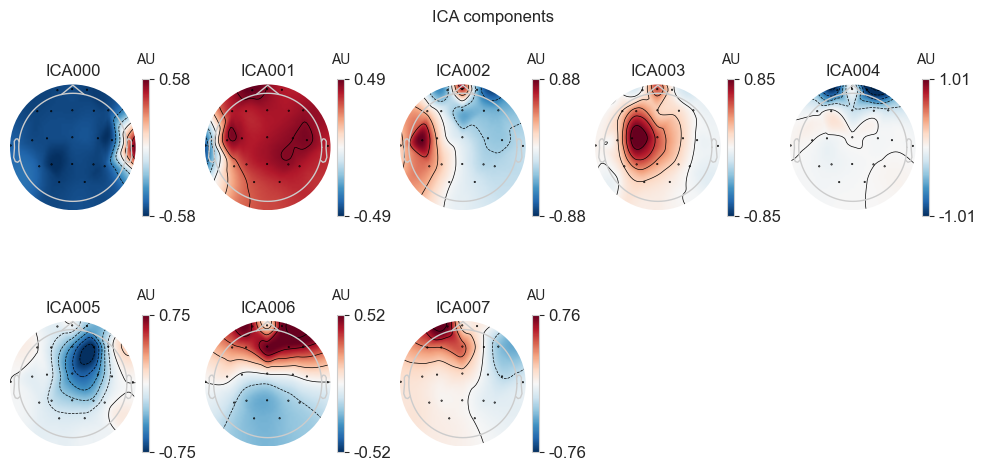

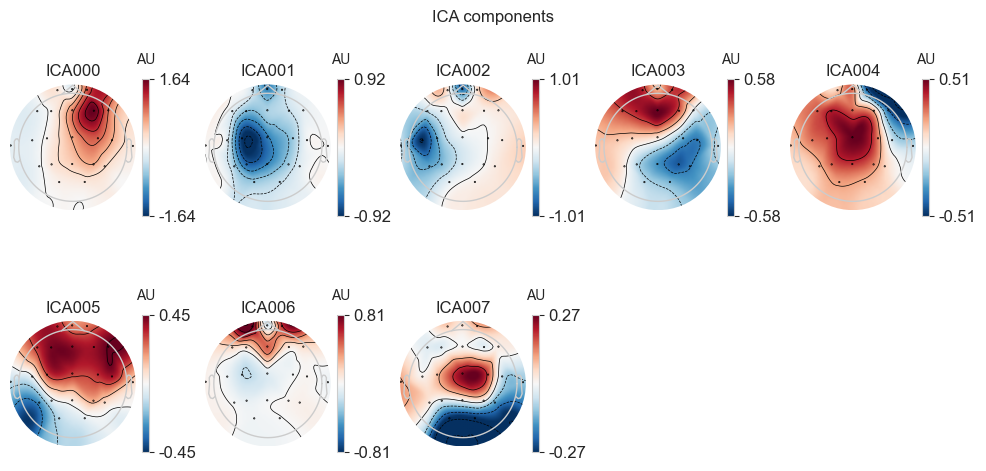

In [30]:
fig_awake = ica_awake.plot_components(colorbar=True)
fig_sleep = ica_sleep.plot_components(colorbar=True)

In [26]:
print("Finding blink components using Fp1 and Fp2...")
ica_awake.exclude = []
ica_sleep.exclude = []

Finding blink components using Fp1 and Fp2...


In [28]:
eog_indices_awake, eog_scores_awake = ica_awake.find_bads_eog(
    raw_awake_1020_for_ica,
    ch_name=['Fp1', 'Fp2']
)
eog_indices_sleep, eog_scores_sleep = ica_sleep.find_bads_eog(
    raw_sleep_1020_for_ica,
    ch_name=['Fp1', 'Fp2']
)

Using EOG channels: Fp1, Fp2


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 sam

In [29]:
ica_awake.exclude = eog_indices_awake
ica_sleep.exclude = eog_indices_sleep
print(f"✓ Identified {len(eog_indices_awake)} EOG components in awake data: {eog_indices_awake}")
print(f"✓ Identified {len(eog_indices_sleep)} EOG components in sleep data: {eog_indices_sleep}")

✓ Identified 0 EOG components in awake data: []
✓ Identified 0 EOG components in sleep data: []


In [31]:
if len(ica.exclude) > 0:
    print("Plotting properties of excluded components...")
    ica.plot_properties(raw_for_ica, picks=ica.exclude)
    plt.show()
else:
    print("WARNING: No blink components were found automatically.")
    print("Please inspect the plot_components() output and set ica.exclude manually.")

Please inspect the plot_components() output and set ica.exclude manually.


In [32]:
ica_awake.exclude = [1,6]
ica_sleep.exclude = [6]

## Step 8: Apply Artifact Removal

In [33]:
raw_clean_awake_1020 = ica_awake.apply(raw_awake_1020.copy(), exclude=ica_awake.exclude)
print("✓ Applied ICA to remove blink artifacts from awake data.")
raw_clean_sleep_1020 = ica_sleep.apply(raw_sleep_1020.copy(), exclude=ica_sleep.exclude)
print("✓ Applied ICA to remove blink artifacts from sleep data.")

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 2 ICA components
    Projecting back using 22 PCA components
✓ Applied ICA to remove blink artifacts from awake data.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 1 ICA component
    Projecting back using 22 PCA components
✓ Applied ICA to remove blink artifacts from sleep data.


## Step 9: Verify the Results

In [34]:
print("Plotting 'before' (top) and 'after' (bottom) data for Fp1/Fp2.")

# Channels to plot
plot_channels = ['Fp1', 'Fp2', 'F7', 'F8']

Plotting 'before' (top) and 'after' (bottom) data for Fp1/Fp2.


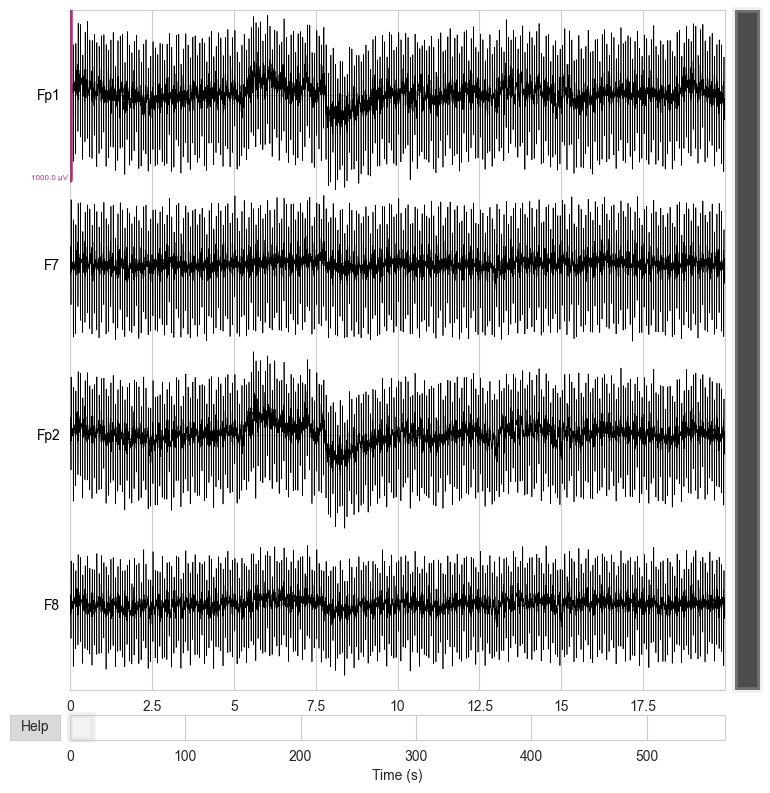

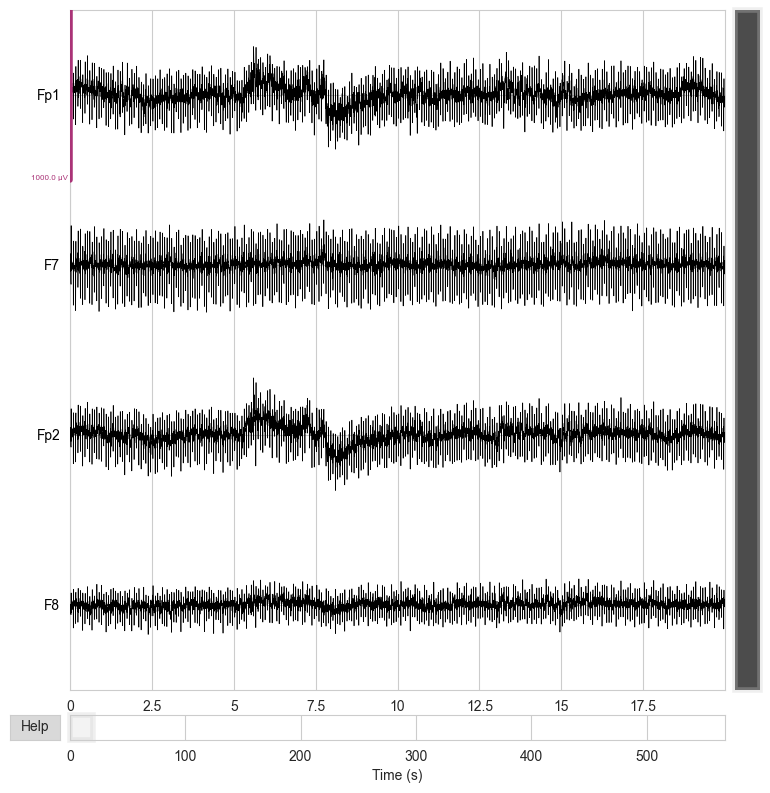

In [41]:
fig1 = raw_awake_1020.plot(
    picks=plot_channels,
    start=0,
    duration=20,
    title="BEFORE ICA: Blinks are present",
    scalings=dict(eeg=50e-5) # 50 uV
)

fig2 = raw_clean_awake_1020.plot(
    picks=plot_channels,
    start=0,
    duration=20,
    title="AFTER ICA: Blinks have been removed",
    scalings=dict(eeg=50e-5) # 50 uV
)

Plotting ICA overlay... (Original = black, Cleaned = red)
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 2 ICA components
    Projecting back using 22 PCA components


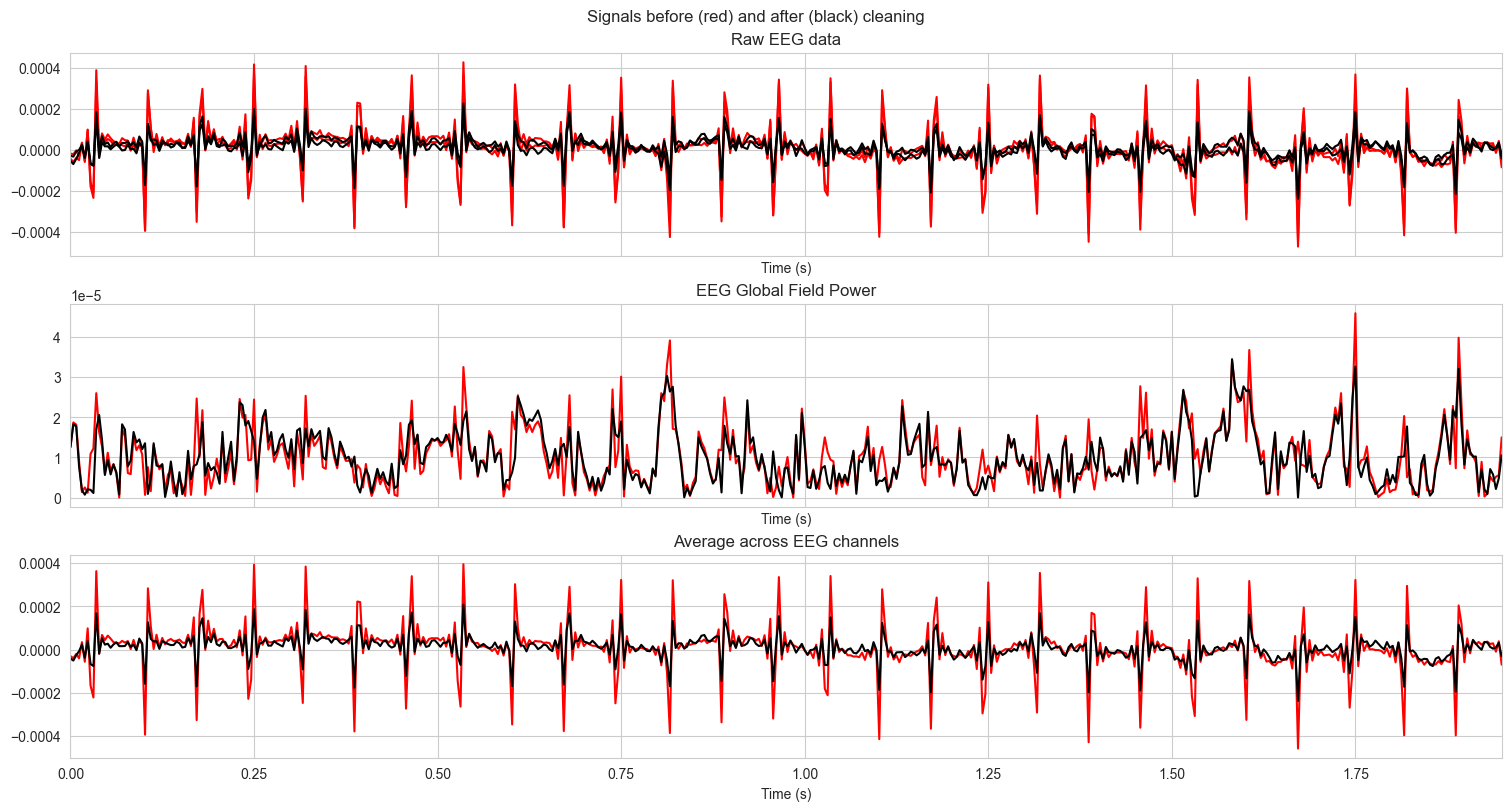

In [47]:
print("Plotting ICA overlay... (Original = black, Cleaned = red)")
fig = ica_awake.plot_overlay(
    raw_awake_1020,
    exclude=ica_awake.exclude,
    picks=['Fp1', 'Fp2'], # Look at the blink channels
    start=0,
    stop=500
)